# 03. Exploratory Data Analysis
## Digital Burnout International Dataset

- Khám phá đặc điểm phân phối của các nhóm biến liên quan Digital Burnout.
- Phân tích các nhóm chỉ báo theo Digital Burnout Indicator Framework.
- Quan sát mối quan hệ sơ bộ giữa các nhóm biến.
- Tạo cơ sở cho bước Feature Validation và DBI Development.

## Import thư viện

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Load Cleaned Dataset

Dữ liệu đầu vào là dataset đã được làm sạch từ notebook:

`02_cleaning_preprocessing.ipynb`

Notebook này không khảo sát lại missing values, duplicates hoặc data types vì các bước đó đã được xử lý ở hai notebook trước.

In [2]:
file_path = "../../data/processed/international_dataset/digital_burnout_cleaned.csv"

df = pd.read_csv(file_path)

print("Cleaned dataset loaded successfully.")
print(f"Shape: {df.shape}")

Cleaned dataset loaded successfully.
Shape: (5000000, 34)


## 2. Define DBI Construct Groups

Các biến được nhóm theo Digital Burnout Indicator Framework ở mức phân tích khám phá.

Việc phân nhóm này giúp EDA bám sát mục tiêu nghiên cứu:

- Burnout Symptoms
- Digital Exposure
- Cognitive Performance
- Sleep & Recovery
- Context Variables

Lưu ý:

Đây chưa phải là bước kiểm chứng chỉ báo. Việc kiểm chứng sẽ được thực hiện trong notebook Feature Validation.

In [3]:
burnout_variables = [
    "burnout_risk",
    "emotional_exhaustion",
    "stress_level",
    "mental_fatigue"
]

digital_exposure_variables = [
    "daily_screen_time",
    "social_media_hours",
    "doomscrolling_duration",
    "late_night_device_usage",
    "notification_count",
    "smartphone_unlocks",
    "app_switch_frequency"
]

cognitive_variables = [
    "concentration_score",
    "distraction_frequency",
    "focus_sessions",
    "deep_work_hours",
    "task_completion_rate",
    "motivation_level",
    "productivity_score"
]

sleep_recovery_variables = [
    "sleep_hours",
    "sleep_quality"
]

context_variables = [
    "work_mode",
    "device_usage_type"
]

In [4]:
def keep_available_columns(dataframe, columns):
    return [col for col in columns if col in dataframe.columns]

burnout_variables = keep_available_columns(df, burnout_variables)
digital_exposure_variables = keep_available_columns(df, digital_exposure_variables)
cognitive_variables = keep_available_columns(df, cognitive_variables)
sleep_recovery_variables = keep_available_columns(df, sleep_recovery_variables)
context_variables = keep_available_columns(df, context_variables)

construct_groups = {
    "Burnout Symptoms": burnout_variables,
    "Digital Exposure": digital_exposure_variables,
    "Cognitive Performance": cognitive_variables,
    "Sleep & Recovery": sleep_recovery_variables,
    "Context Variables": context_variables
}

construct_summary = pd.DataFrame({
    "construct_group": list(construct_groups.keys()),
    "variables": [", ".join(values) for values in construct_groups.values()],
    "number_of_variables": [len(values) for values in construct_groups.values()]
})

display(construct_summary)

,construct_group,variables,number_of_variables
0,Burnout Symptoms,"burnout_risk, emotional_exhaustion, stress_lev...",4
1,Digital Exposure,"daily_screen_time, social_media_hours, doomscr...",7
2,Cognitive Performance,"concentration_score, distraction_frequency, fo...",7
3,Sleep & Recovery,"sleep_hours, sleep_quality",2
4,Context Variables,"work_mode, device_usage_type",2


## 3. Helper Functions for EDA

Các hàm dưới đây được dùng để tránh lặp code khi phân tích từng nhóm chỉ báo.

Notebook này chỉ sử dụng:

- Descriptive statistics
- Histogram
- Boxplot
- Countplot
- Correlation heatmap

Không sử dụng kiểm định thống kê chính thức trong notebook này.

In [5]:
def display_descriptive_statistics(dataframe, columns, title):
    available_columns = keep_available_columns(dataframe, columns)
    
    if len(available_columns) == 0:
        print(f"No available variables for {title}.")
        return
    
    print(title)
    display(dataframe[available_columns].describe().T)


def plot_distributions(dataframe, columns, title_prefix):
    available_columns = keep_available_columns(dataframe, columns)
    
    for col in available_columns:
        plt.figure(figsize=(10, 5))
        sns.histplot(dataframe[col], kde=True, bins=30)
        plt.title(f"{title_prefix}: Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()


def plot_boxplots(dataframe, columns, title_prefix):
    available_columns = keep_available_columns(dataframe, columns)
    
    for col in available_columns:
        plt.figure(figsize=(10, 4))
        sns.boxplot(x=dataframe[col])
        plt.title(f"{title_prefix}: Boxplot of {col}")
        plt.xlabel(col)
        plt.show()


def plot_correlation_heatmap(dataframe, columns, title):
    available_columns = keep_available_columns(dataframe, columns)
    
    if len(available_columns) < 2:
        print(f"Not enough variables for correlation heatmap: {title}")
        return
    
    corr_matrix = dataframe[available_columns].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt=".2f",
        linewidths=0.5,
        cmap="Blues"
    )
    plt.title(title)
    plt.show()
    
    return corr_matrix

## 4. Burnout Symptoms Analysis

Nhóm Burnout Symptoms gồm các biến phản ánh mức độ kiệt sức số và trạng thái tâm lý liên quan:

- burnout_risk
- emotional_exhaustion
- stress_level
- mental_fatigue

Mục tiêu:

- Quan sát phân phối của các biến burnout.
- Nhận diện độ phân tán và các giá trị cực đoan.
- Chuẩn bị cơ sở cho Feature Validation.

In [6]:
display_descriptive_statistics(
    df,
    burnout_variables,
    "Descriptive Statistics - Burnout Symptoms"
)

Descriptive Statistics - Burnout Symptoms


,count,mean,std,min,25%,50%,75%,max
burnout_risk,5000000.0,48.583744,22.072030,0.0,33.0,48.0,64.0,100.0
emotional_exhaustion,5000000.0,5.502012,2.871822,1.0,3.0,6.0,8.0,10.0
stress_level,5000000.0,5.499488,2.871430,1.0,3.0,5.0,8.0,10.0
mental_fatigue,5000000.0,5.499560,2.872018,1.0,3.0,5.0,8.0,10.0


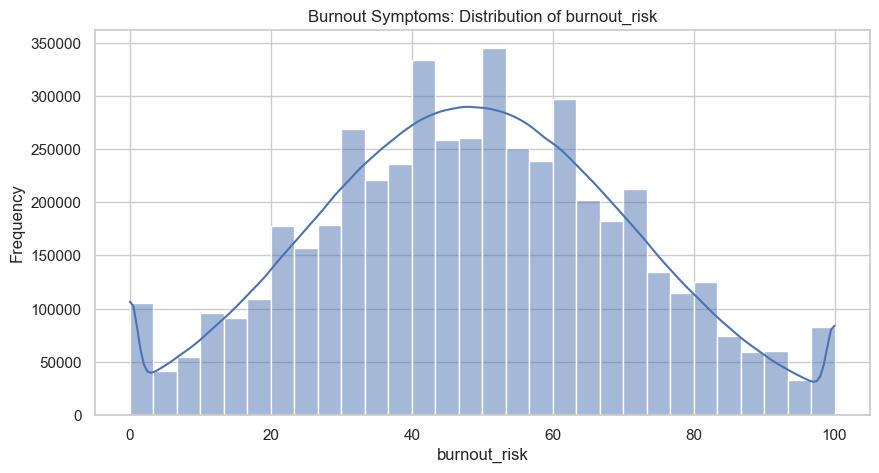

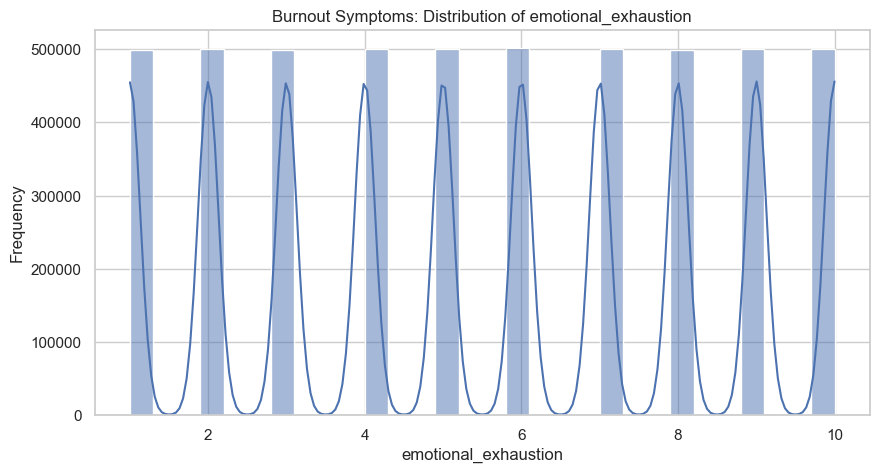

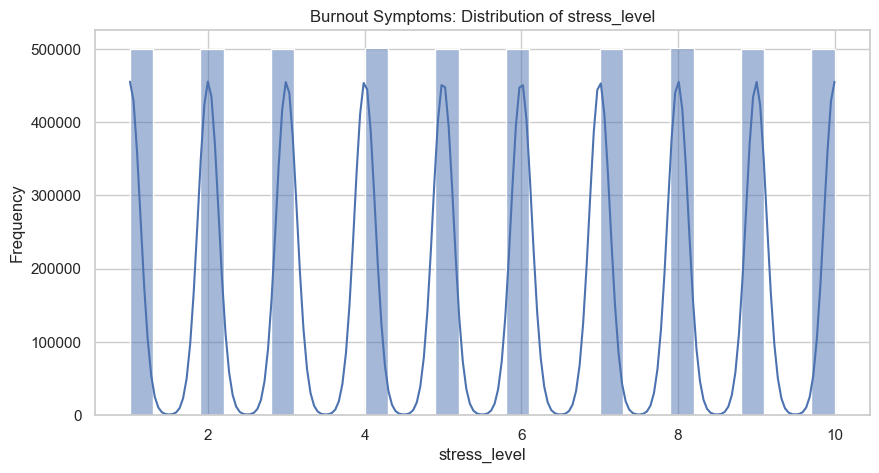

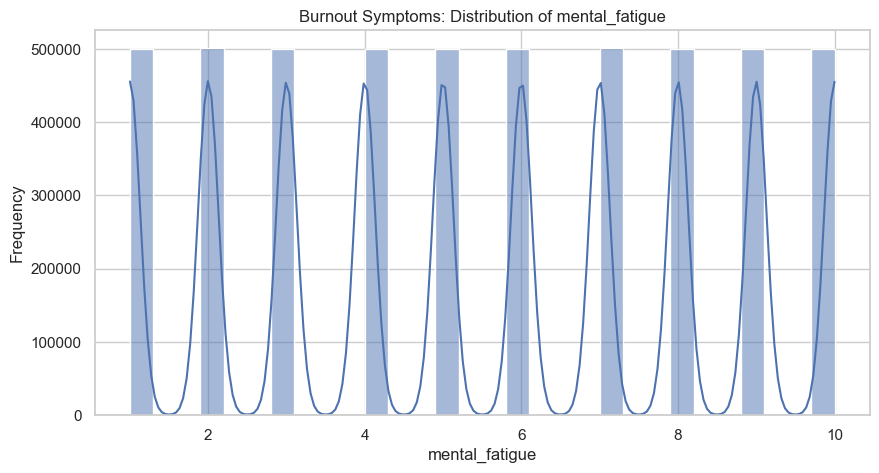

In [7]:
plot_distributions(
    df,
    burnout_variables,
    "Burnout Symptoms"
)

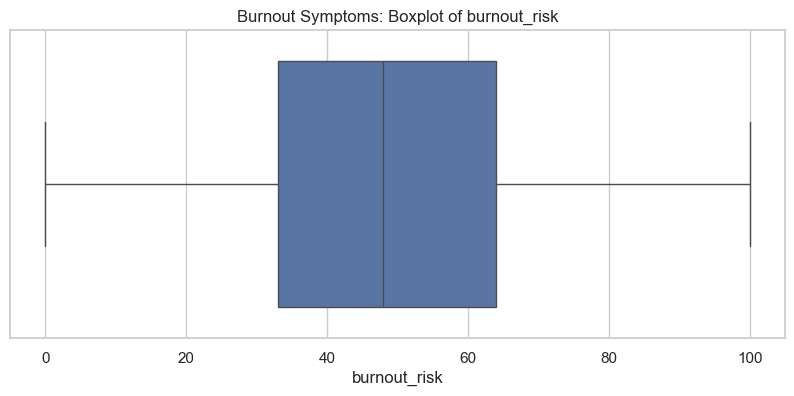

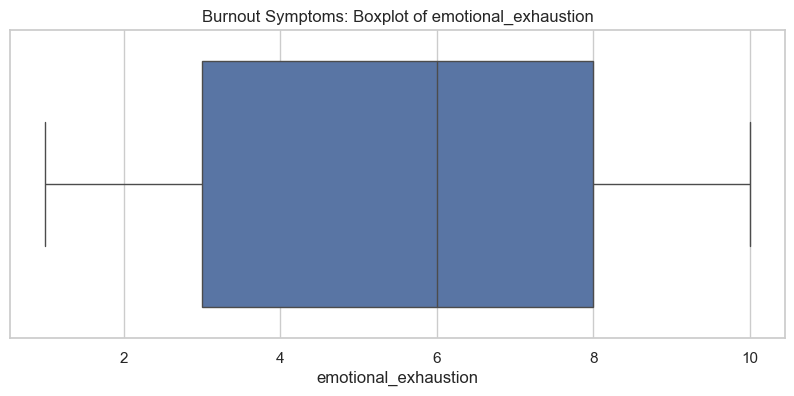

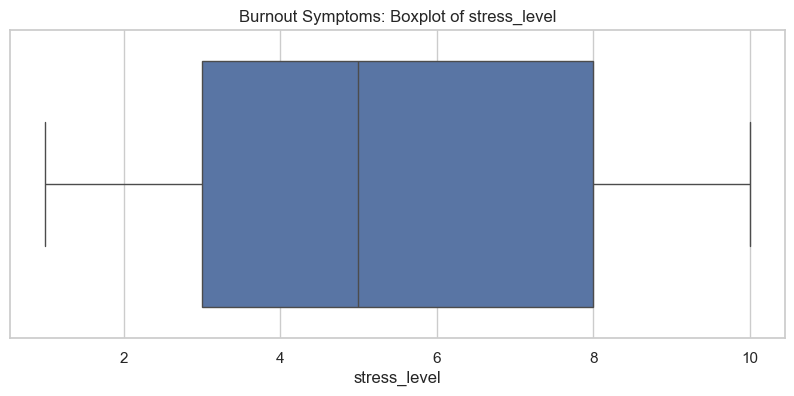

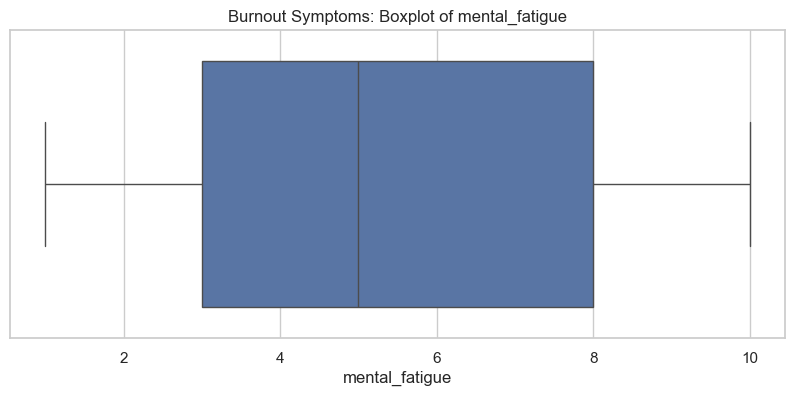

In [8]:
plot_boxplots(
    df,
    burnout_variables,
    "Burnout Symptoms"
)

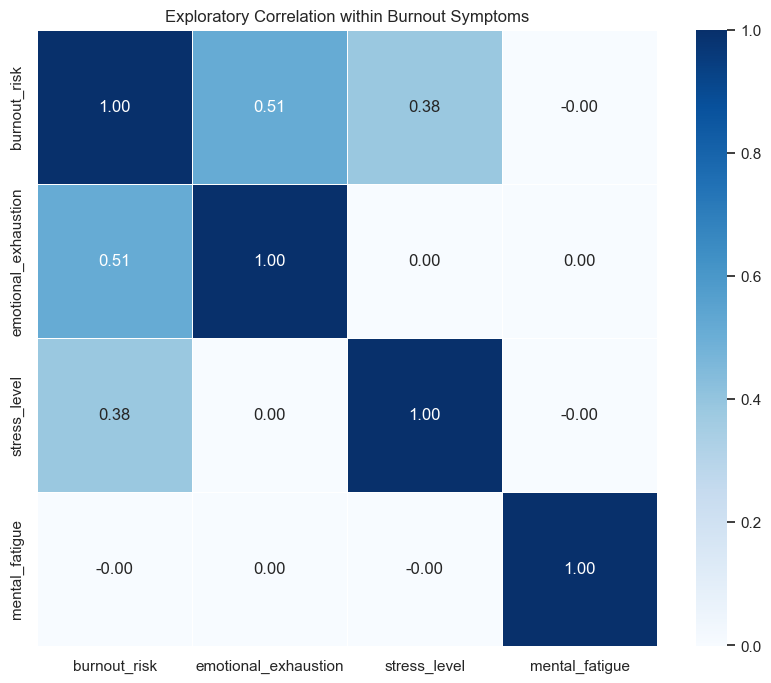

In [9]:
burnout_corr = plot_correlation_heatmap(
    df,
    burnout_variables,
    "Exploratory Correlation within Burnout Symptoms"
)

## 5. Digital Exposure Analysis

Nhóm Digital Exposure phản ánh mức độ tiếp xúc và hành vi sử dụng thiết bị số.

Các biến gồm:

- daily_screen_time
- social_media_hours
- doomscrolling_duration
- late_night_device_usage
- notification_count
- smartphone_unlocks
- app_switch_frequency

Mục tiêu:

- Quan sát cường độ sử dụng thiết bị.
- Xác định biến có độ phân tán lớn.
- Khám phá các hành vi số có thể liên quan đến Digital Burnout.

In [10]:
display_descriptive_statistics(
    df,
    digital_exposure_variables,
    "Descriptive Statistics - Digital Exposure"
)

Descriptive Statistics - Digital Exposure


,count,mean,std,min,25%,50%,75%,max
daily_screen_time,5000000.0,8.001010,2.494805,1.0,6.3,8.0,9.7,18.0
social_media_hours,5000000.0,3.517298,1.741753,0.0,2.3,3.5,4.7,12.0
doomscrolling_duration,5000000.0,1.834645,1.132208,0.0,1.0,1.8,2.6,7.9
late_night_device_usage,5000000.0,0.649993,0.476972,0.0,0.0,1.0,1.0,1.0
notification_count,5000000.0,209.437953,109.664564,20.0,114.0,209.0,304.0,399.0
smartphone_unlocks,5000000.0,157.043114,82.281616,15.0,86.0,157.0,228.0,299.0
app_switch_frequency,5000000.0,129.498100,69.281448,10.0,69.0,129.0,190.0,249.0


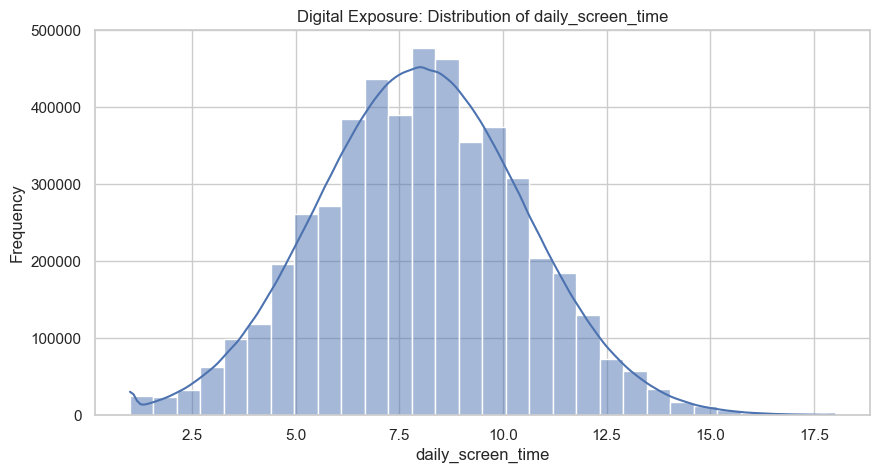

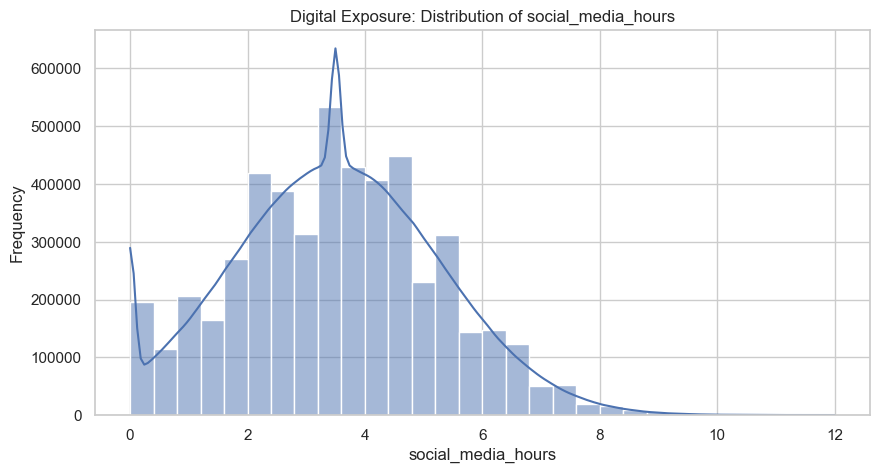

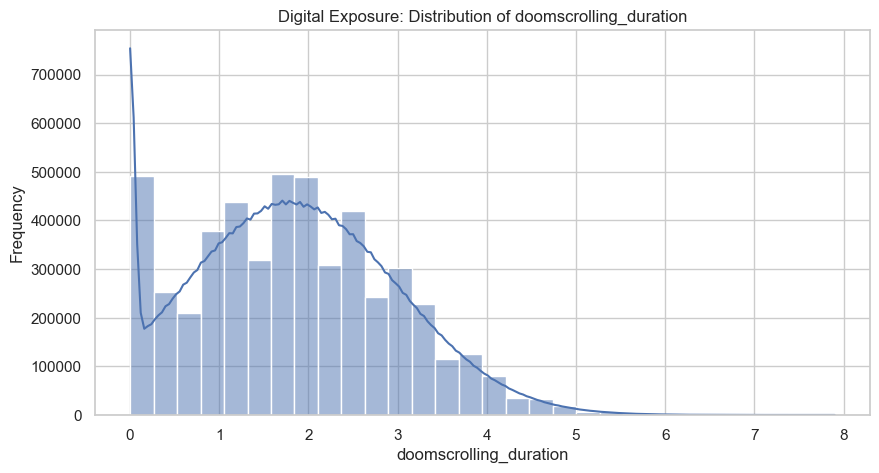

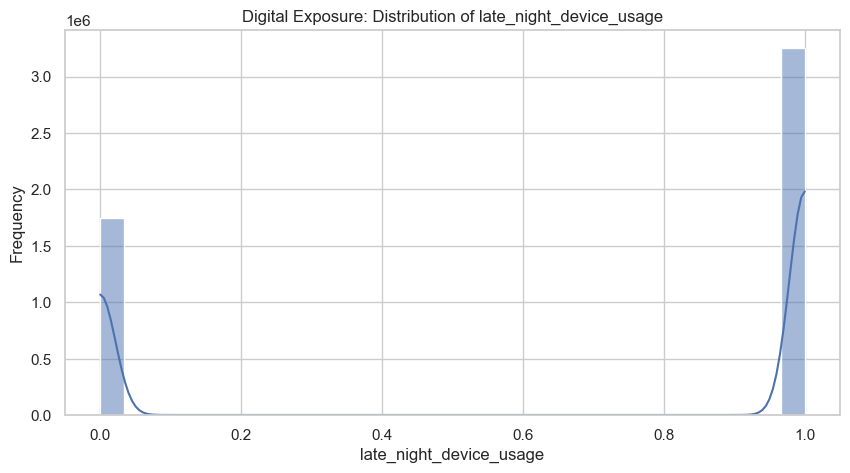

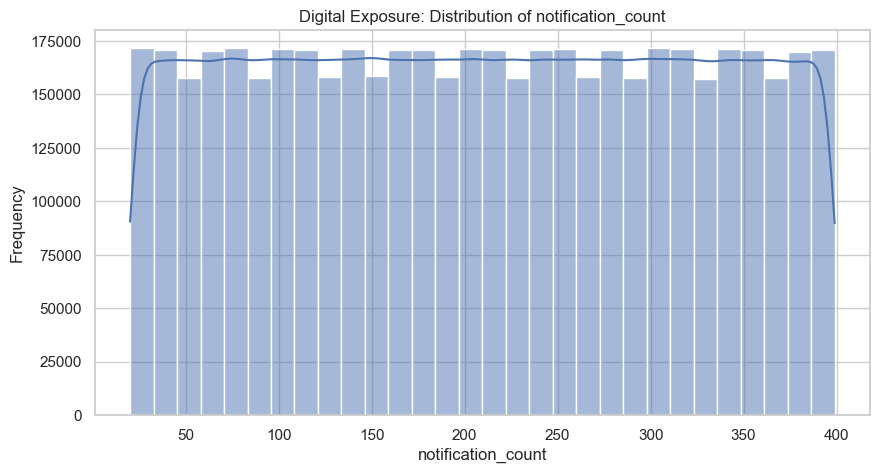

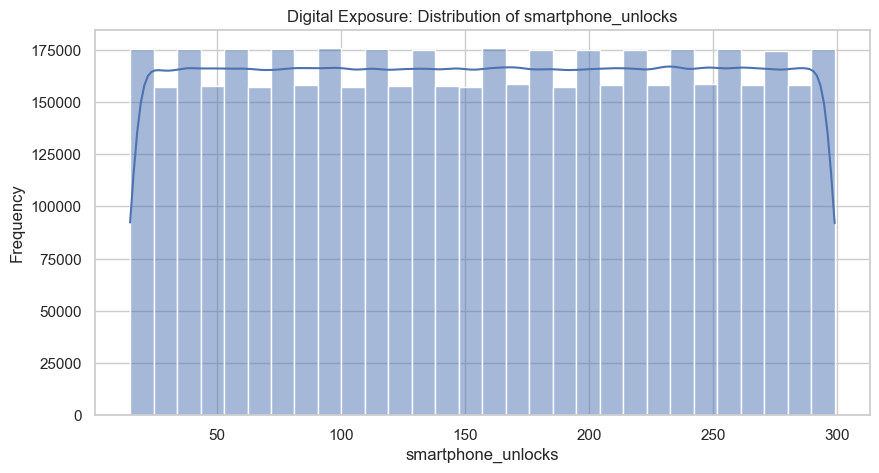

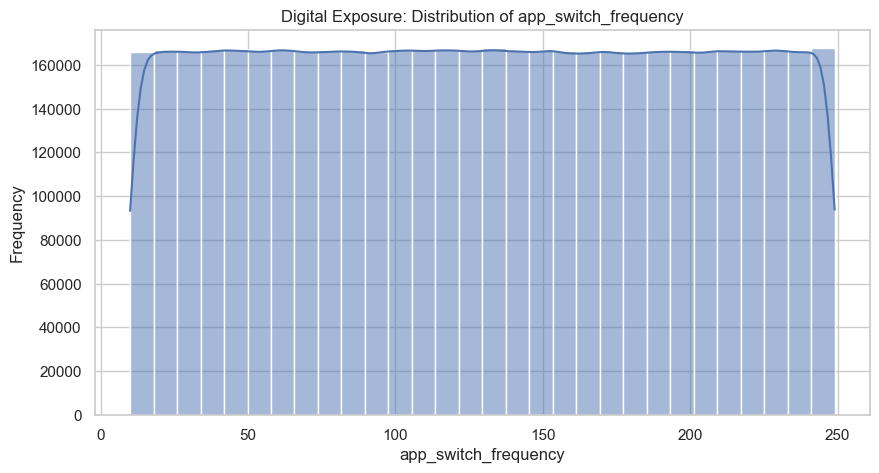

In [11]:
plot_distributions(
    df,
    digital_exposure_variables,
    "Digital Exposure"
)

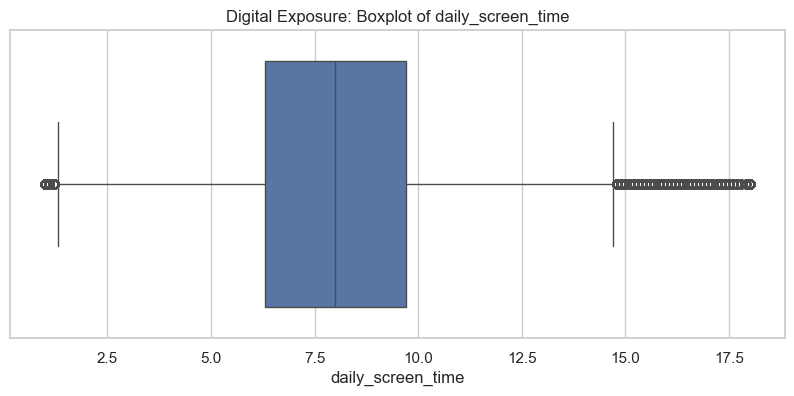

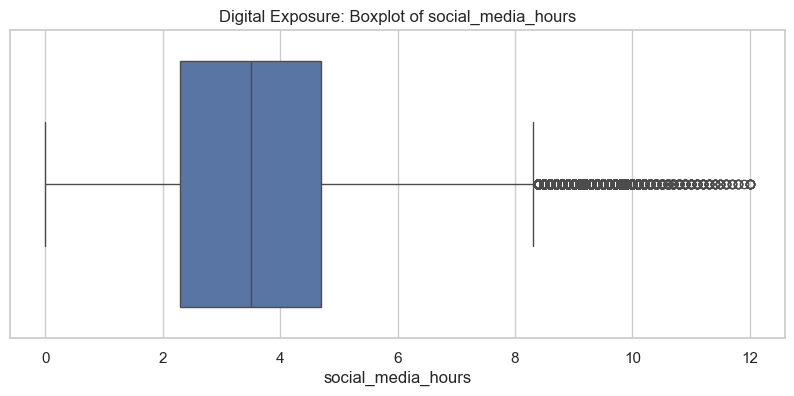

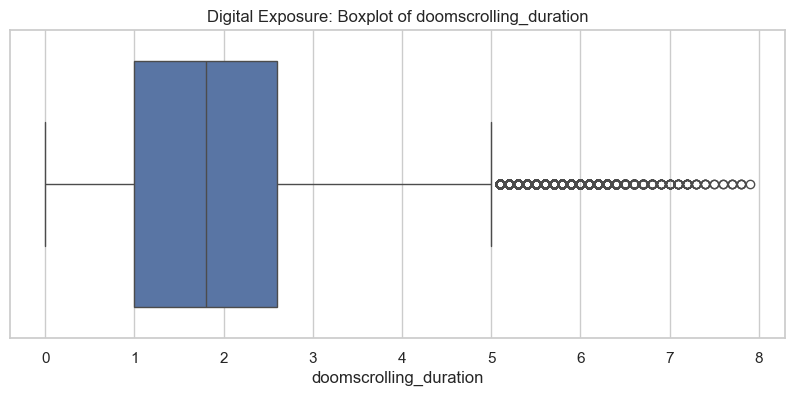

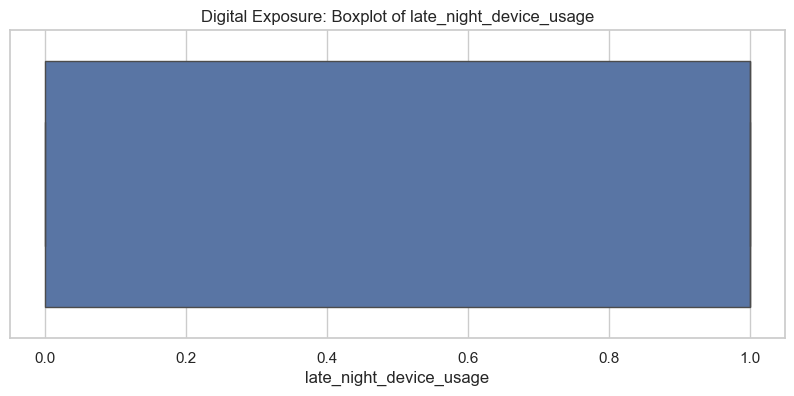

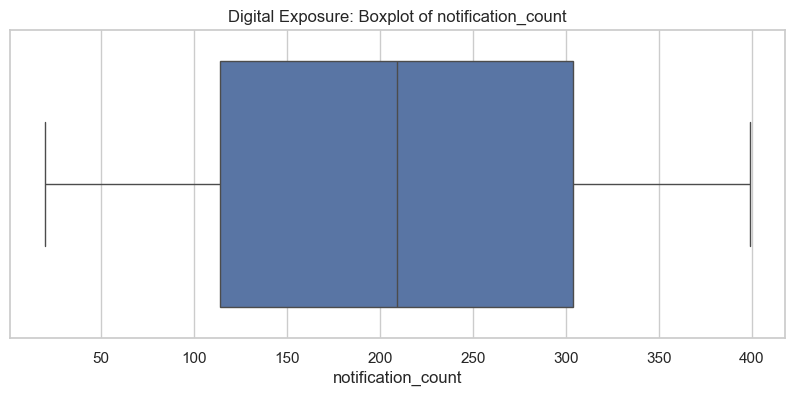

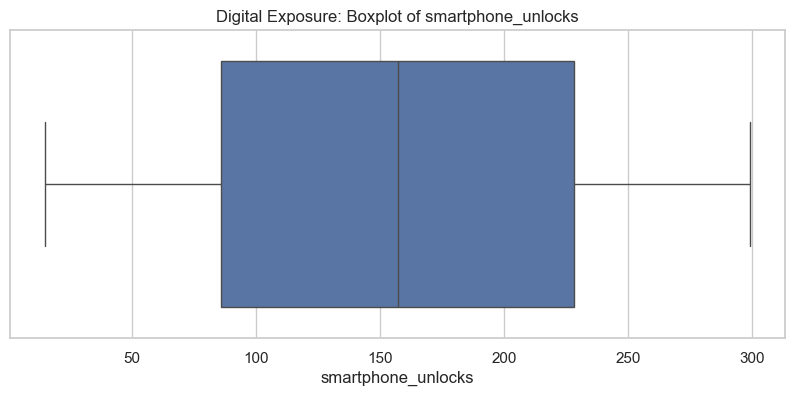

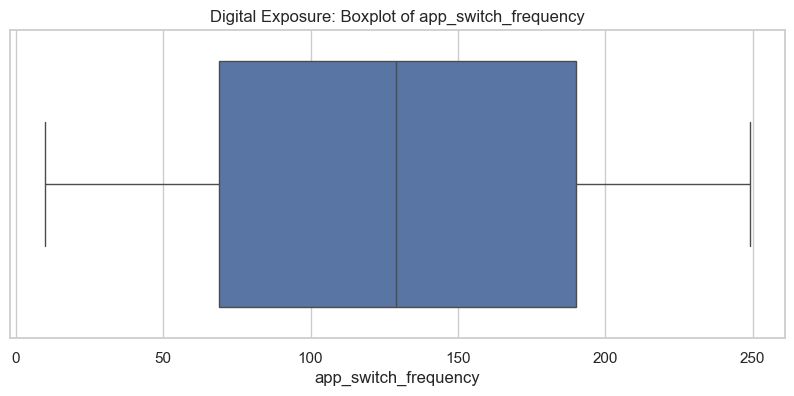

In [12]:
plot_boxplots(
    df,
    digital_exposure_variables,
    "Digital Exposure"
)

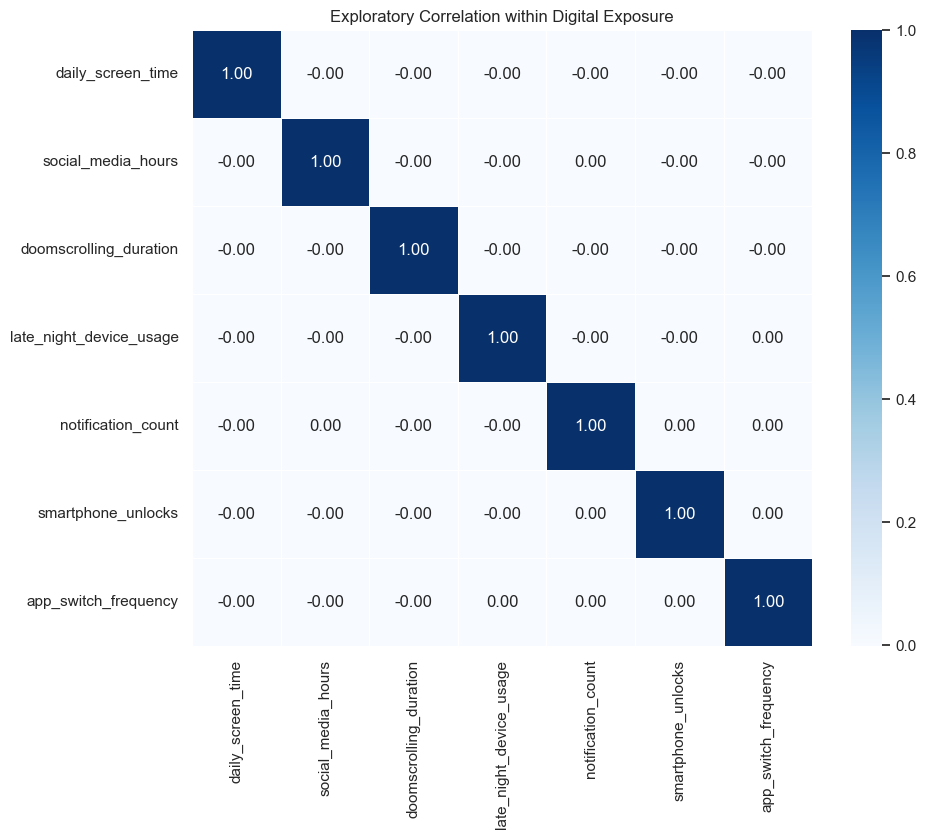

In [13]:
digital_exposure_corr = plot_correlation_heatmap(
    df,
    digital_exposure_variables,
    "Exploratory Correlation within Digital Exposure"
)

## 6. Cognitive Performance Analysis

Nhóm Cognitive Performance phản ánh khả năng tập trung, hiệu suất và mức độ hoàn thành công việc/học tập.

Các biến gồm:

- concentration_score
- distraction_frequency
- focus_sessions
- deep_work_hours
- task_completion_rate
- motivation_level
- productivity_score

Mục tiêu:

- Khám phá đặc điểm phân phối của các biến hiệu suất nhận thức.
- Quan sát sự khác biệt giữa các biến tích cực và tiêu cực.
- Chuẩn bị nền tảng cho kiểm chứng chỉ báo ở bước sau.

In [14]:
display_descriptive_statistics(
    df,
    cognitive_variables,
    "Descriptive Statistics - Cognitive Performance"
)

Descriptive Statistics - Cognitive Performance


,count,mean,std,min,25%,50%,75%,max
concentration_score,5000000.0,5.501229,2.871775,1.0,3.0,6.0,8.0,10.0
distraction_frequency,5000000.0,60.033520,34.350106,1.0,30.0,60.0,90.0,119.0
focus_sessions,5000000.0,4.500512,2.872723,0.0,2.0,5.0,7.0,9.0
deep_work_hours,5000000.0,3.034620,1.707735,0.0,1.8,3.0,4.2,11.8
task_completion_rate,5000000.0,69.997287,17.601238,40.0,55.0,70.0,85.0,100.0
motivation_level,5000000.0,5.489457,2.843911,1.0,3.0,5.0,8.0,10.0
productivity_score,5000000.0,71.443967,21.498986,0.0,56.0,73.0,90.0,100.0


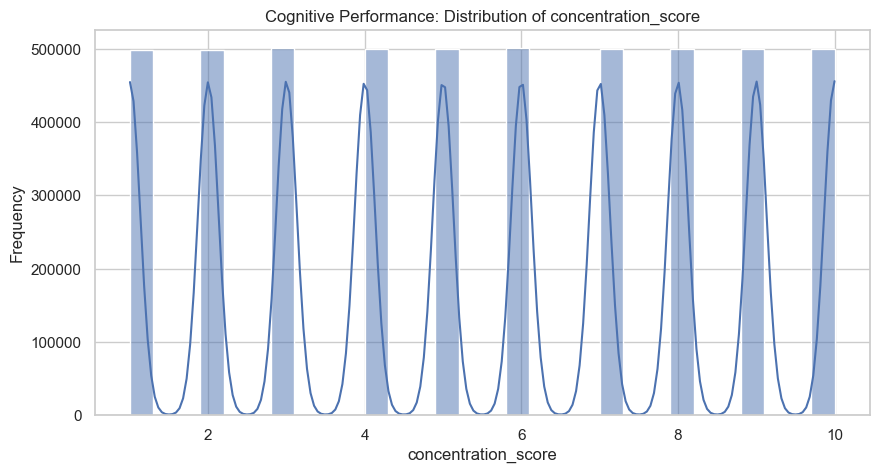

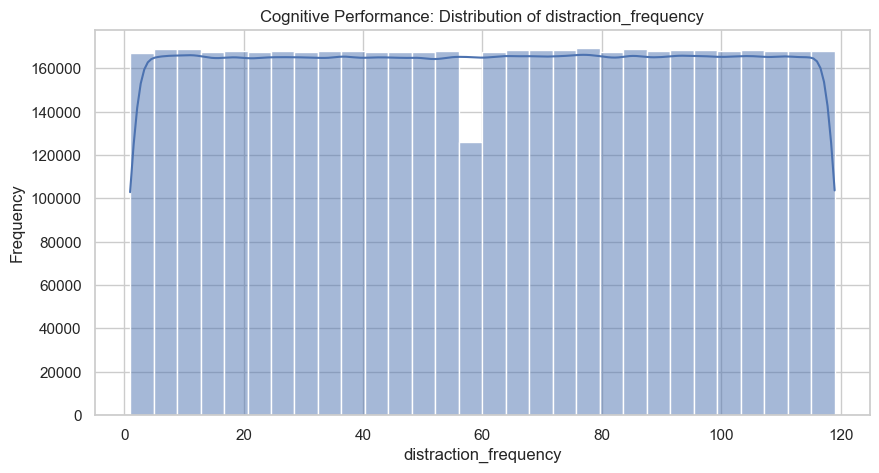

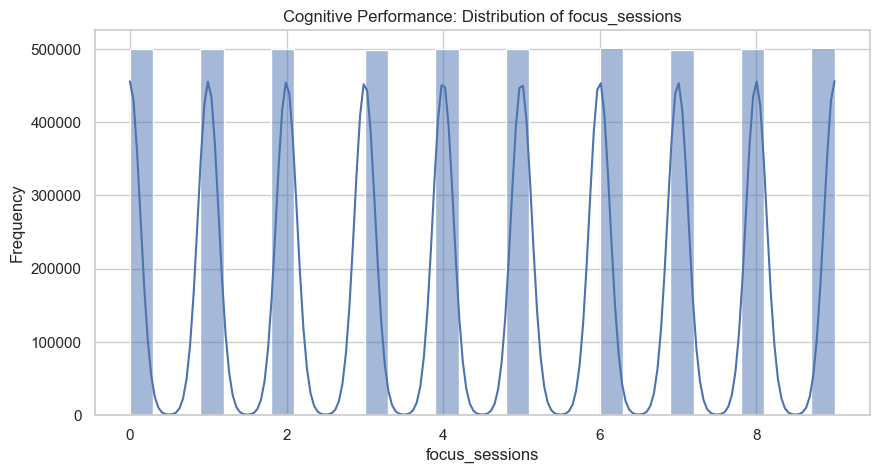

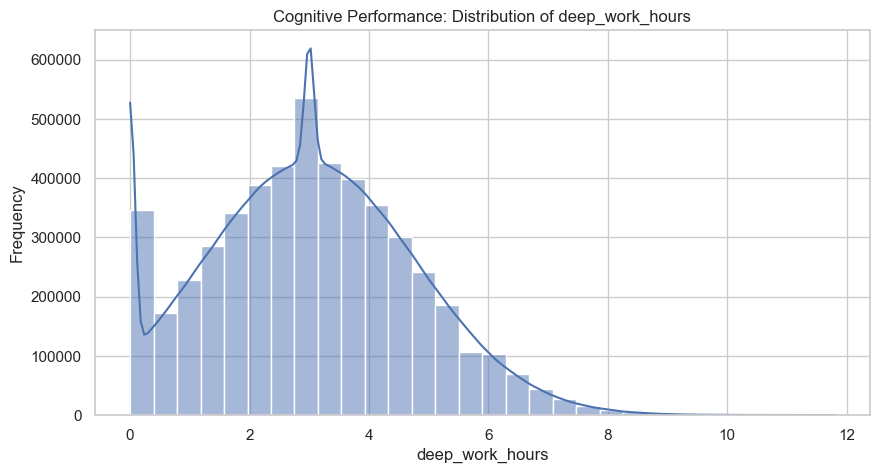

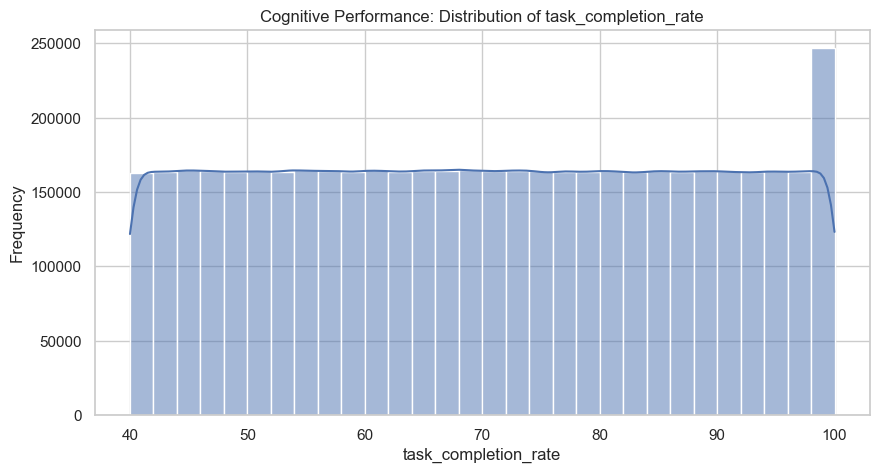

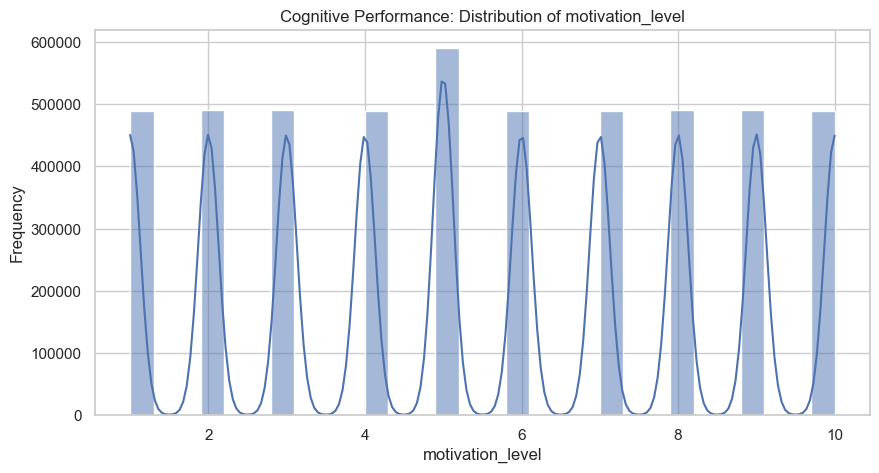

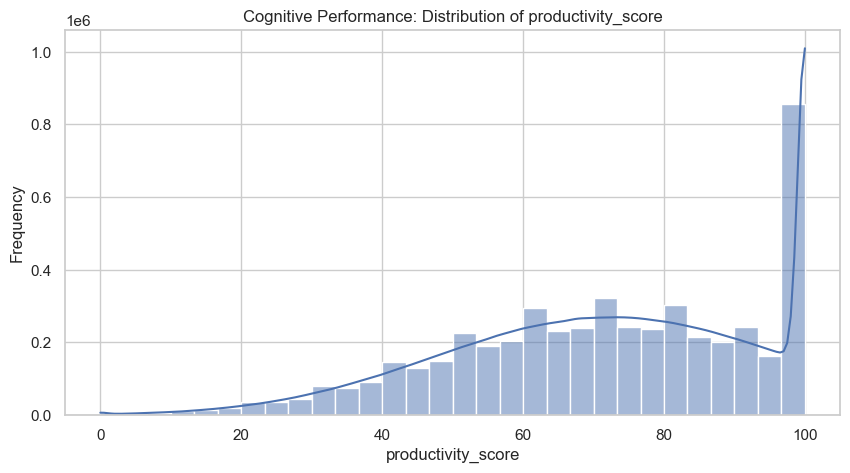

In [15]:
plot_distributions(
    df,
    cognitive_variables,
    "Cognitive Performance"
)

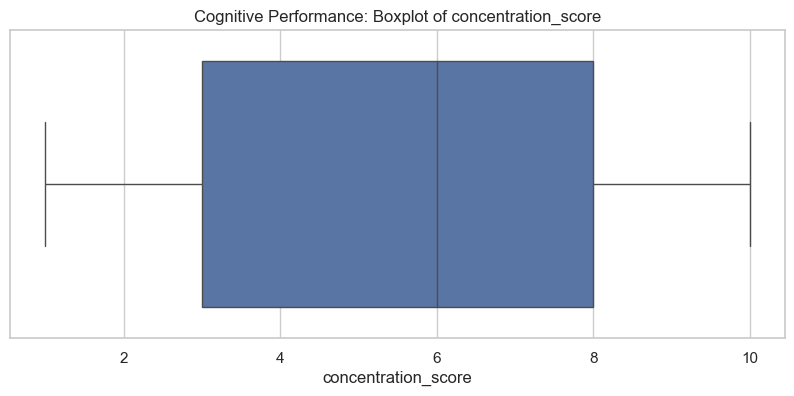

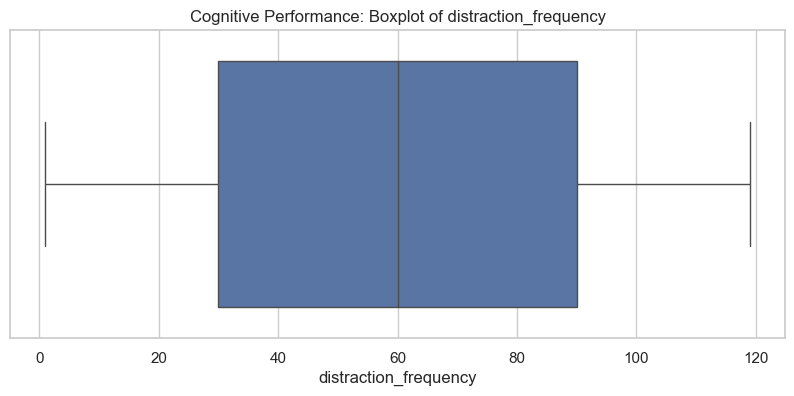

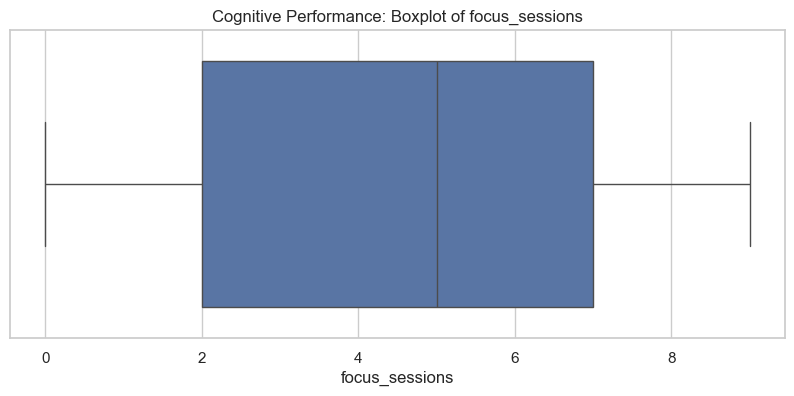

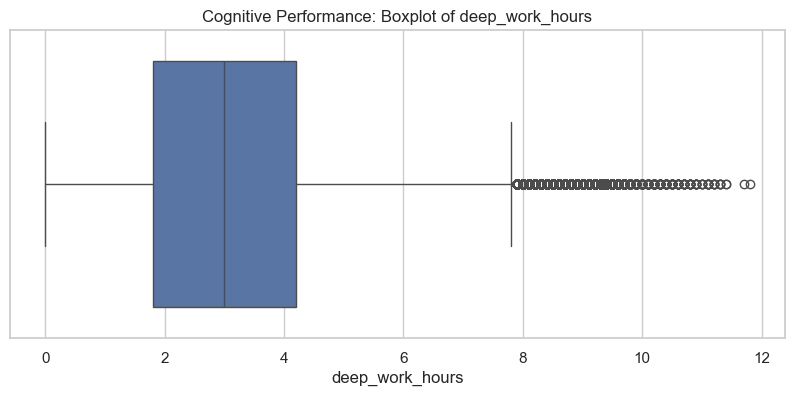

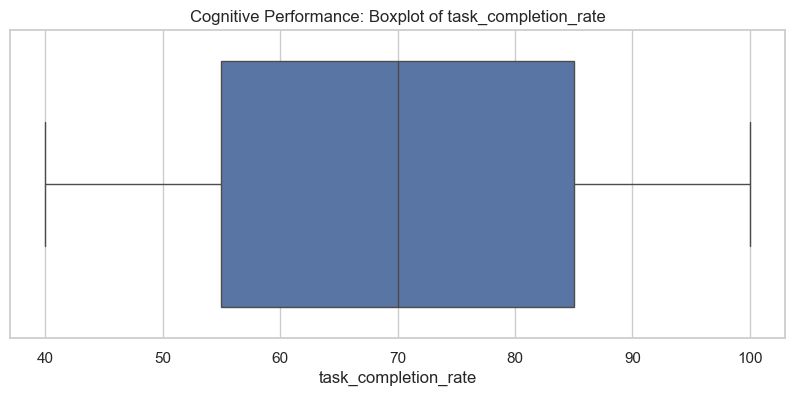

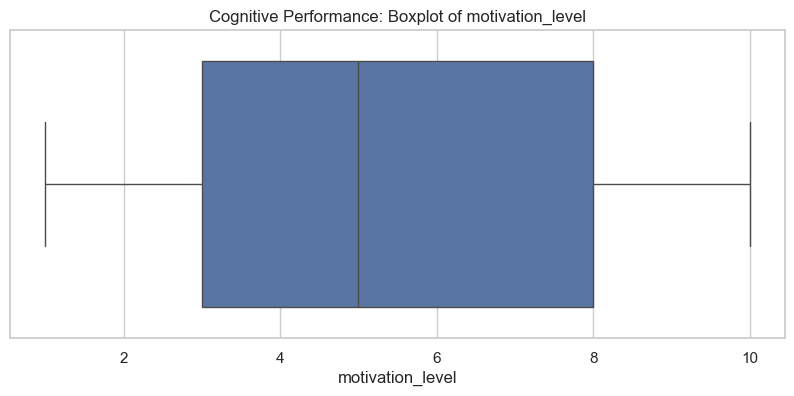

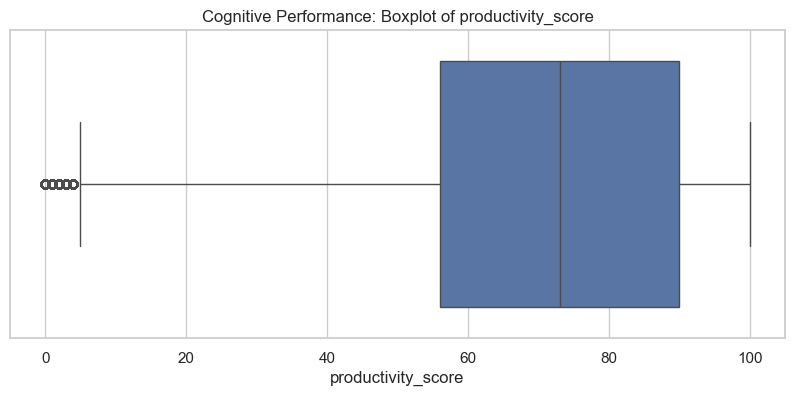

In [16]:
plot_boxplots(
    df,
    cognitive_variables,
    "Cognitive Performance"
)

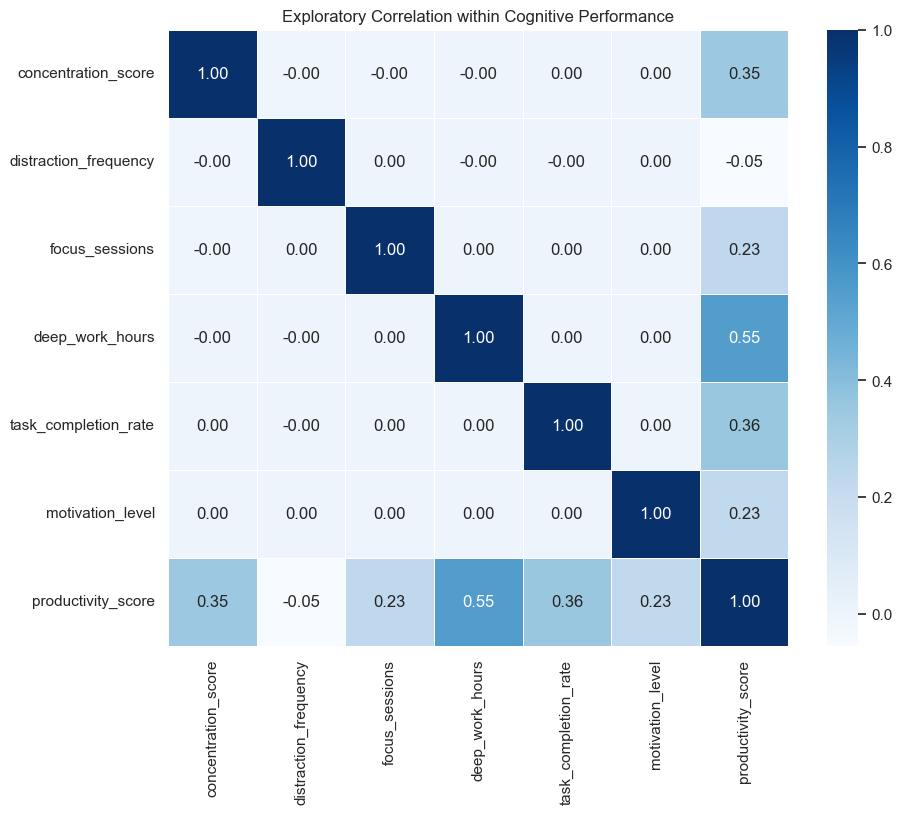

In [17]:
cognitive_corr = plot_correlation_heatmap(
    df,
    cognitive_variables,
    "Exploratory Correlation within Cognitive Performance"
)

## 7. Sleep & Recovery Analysis

Nhóm Sleep & Recovery phản ánh khả năng phục hồi của sinh viên thông qua giấc ngủ.

Các biến gồm:

- sleep_hours
- sleep_quality

Mục tiêu:

- Quan sát phân phối thời lượng và chất lượng giấc ngủ.
- Xác định vai trò tiềm năng của phục hồi trong Digital Burnout.
- Chuẩn bị cho bước kiểm chứng mối quan hệ giữa sleep và burnout.

In [18]:
display_descriptive_statistics(
    df,
    sleep_recovery_variables,
    "Descriptive Statistics - Sleep & Recovery"
)

Descriptive Statistics - Sleep & Recovery


,count,mean,std,min,25%,50%,75%,max
sleep_hours,5000000.0,6.500653,1.458583,3.0,5.5,6.5,7.5,10.0
sleep_quality,5000000.0,5.502620,2.871986,1.0,3.0,6.0,8.0,10.0


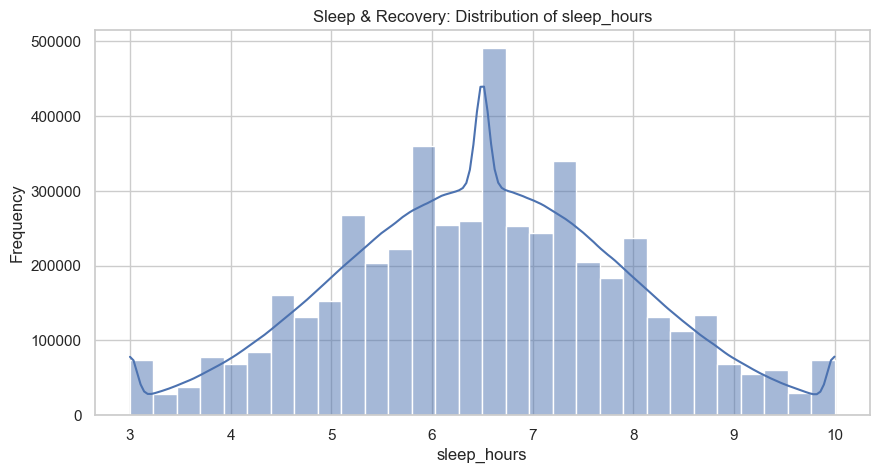

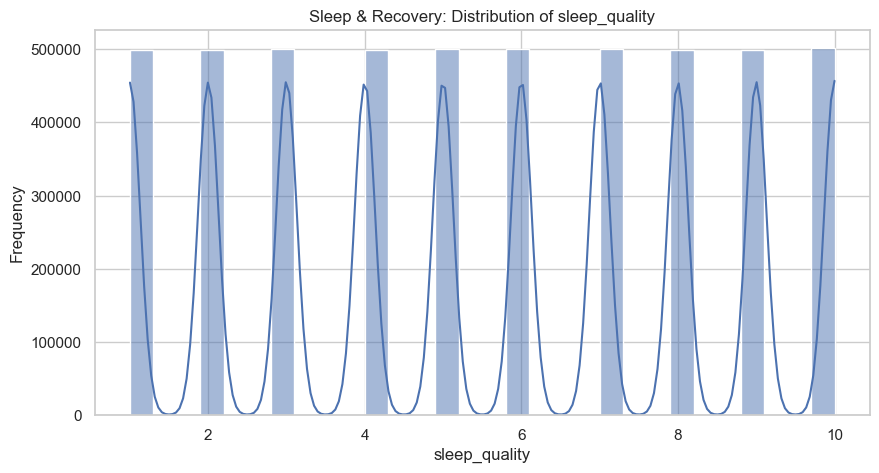

In [19]:
plot_distributions(
    df,
    sleep_recovery_variables,
    "Sleep & Recovery"
)

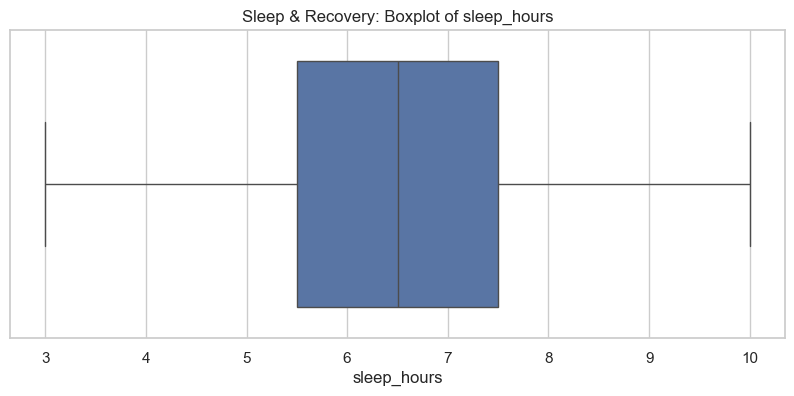

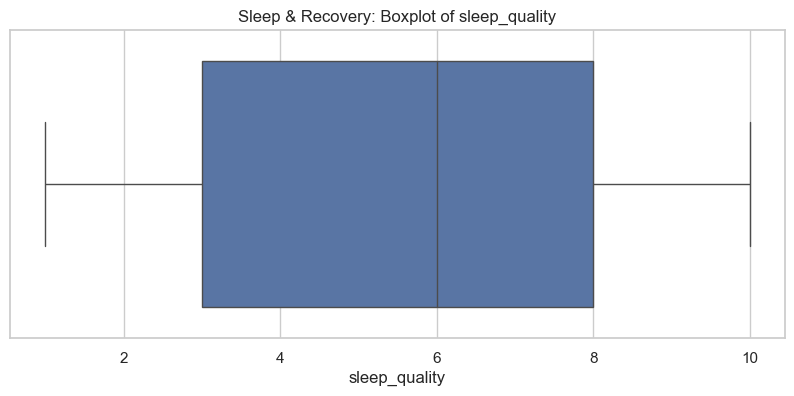

In [20]:
plot_boxplots(
    df,
    sleep_recovery_variables,
    "Sleep & Recovery"
)

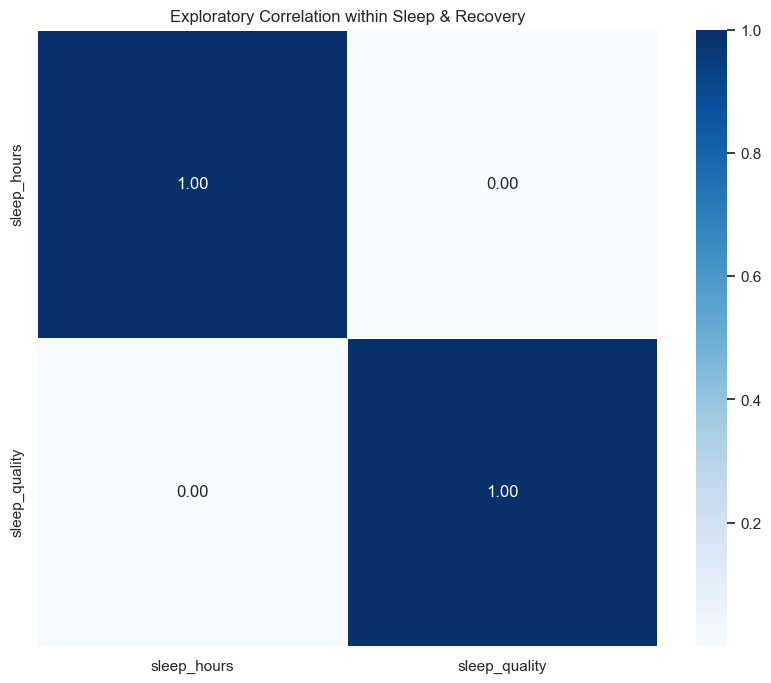

In [21]:
sleep_corr = plot_correlation_heatmap(
    df,
    sleep_recovery_variables,
    "Exploratory Correlation within Sleep & Recovery"
)

## 8. Context Variables Analysis

Nhóm Context Variables phản ánh bối cảnh sử dụng thiết bị hoặc môi trường học tập/làm việc.

Các biến gồm:

- work_mode
- device_usage_type

Mục tiêu:

- Quan sát phân bố của các nhóm bối cảnh.
- Xác định nhóm nào chiếm ưu thế trong dataset.
- Chuẩn bị cho phân tích so sánh nhóm ở mức khám phá.

Frequency table for work_mode:


,count,count
0,Remote,2250774
1,Hybrid,1748165
2,Office,1001061


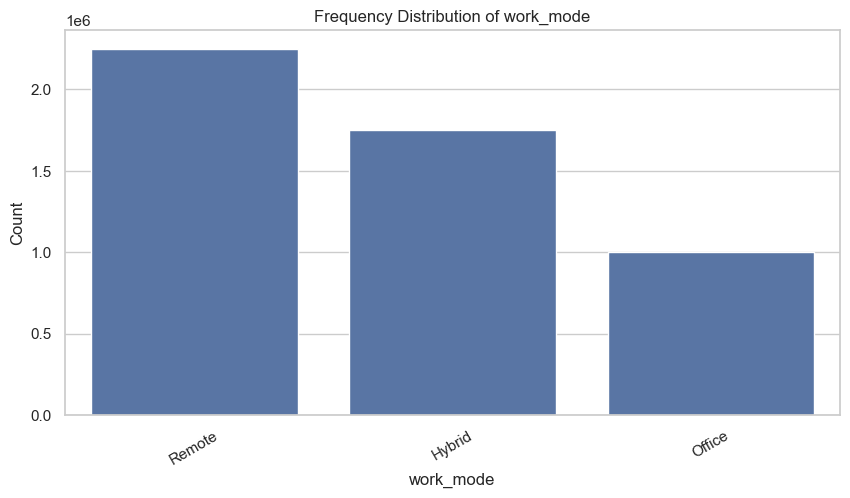

Frequency table for device_usage_type:


,count,count
0,Balanced,1749883
1,Work-Centric,1749379
2,Entertainment-Centric,1500738


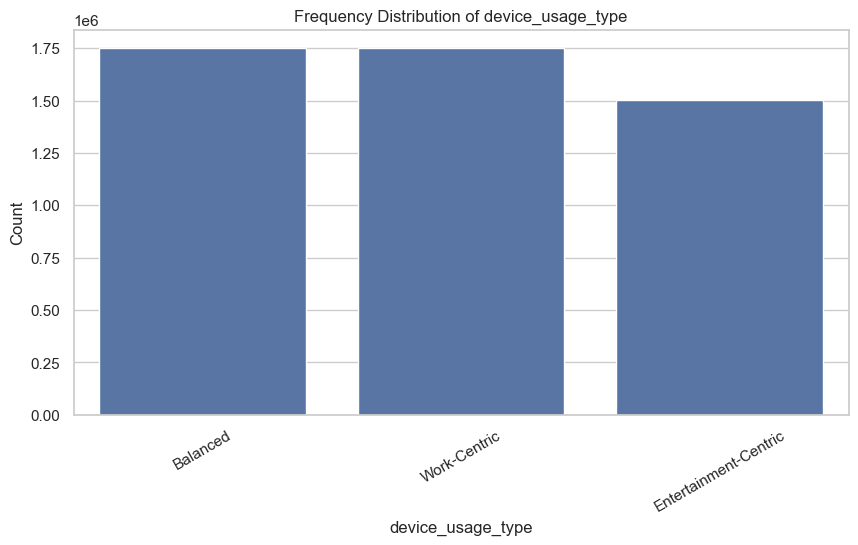

In [22]:
for col in context_variables:
    print(f"Frequency table for {col}:")
    display(df[col].value_counts().reset_index().rename(
        columns={
            "index": col,
            col: "count"
        }
    ))
    
    plt.figure(figsize=(10, 5))
    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )
    plt.title(f"Frequency Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.show()

## 9. Burnout and Digital Exposure Relationship

Phần này quan sát sơ bộ mối quan hệ giữa nhóm Burnout Symptoms và nhóm Digital Exposure.

Mục tiêu:

- Xem các hành vi sử dụng thiết bị có xu hướng liên hệ với burnout hay không.
- Tạo cơ sở cho các kiểm định chính thức ở notebook Feature Validation.

Lưu ý:

Correlation trong notebook này chỉ mang tính khám phá, không dùng để xác nhận chỉ báo hợp lệ.

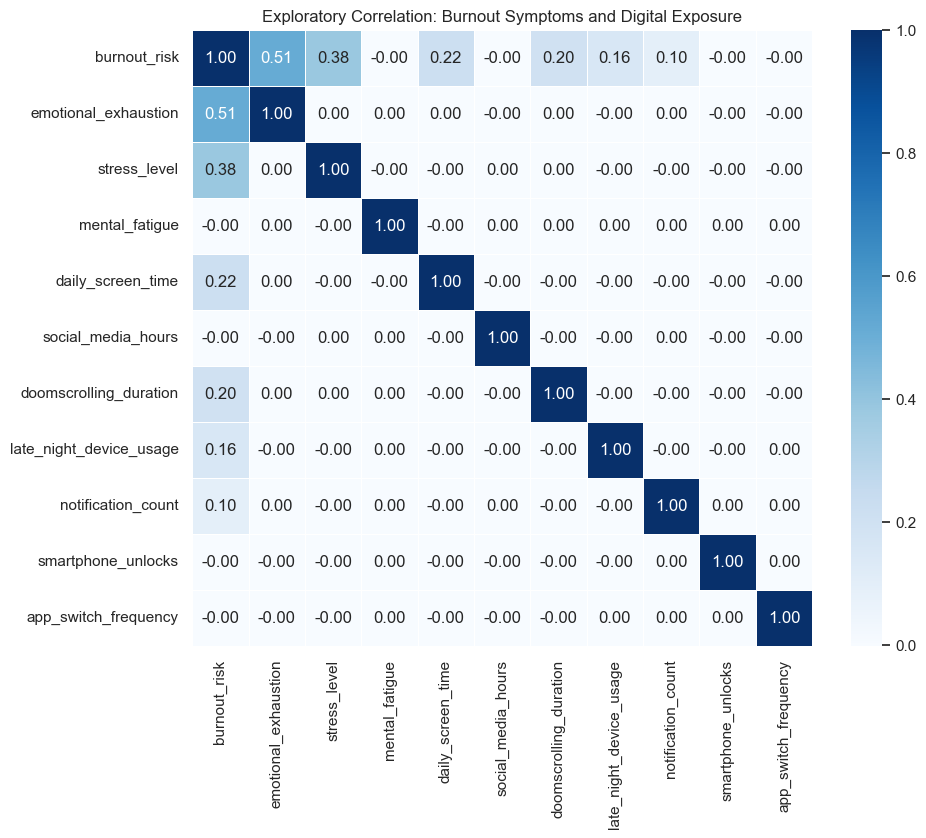

In [23]:
burnout_digital_columns = burnout_variables + digital_exposure_variables

burnout_digital_corr = plot_correlation_heatmap(
    df,
    burnout_digital_columns,
    "Exploratory Correlation: Burnout Symptoms and Digital Exposure"
)

## 10. Burnout and Cognitive Performance Relationship

Phần này quan sát sơ bộ mối quan hệ giữa Burnout Symptoms và Cognitive Performance.

Mục tiêu:

- Khám phá liệu burnout có xu hướng đi kèm với giảm tập trung, giảm động lực hoặc giảm năng suất hay không.
- Chuẩn bị câu hỏi nghiên cứu cho bước Feature Validation.

Không kết luận quan hệ nhân quả trong notebook này.

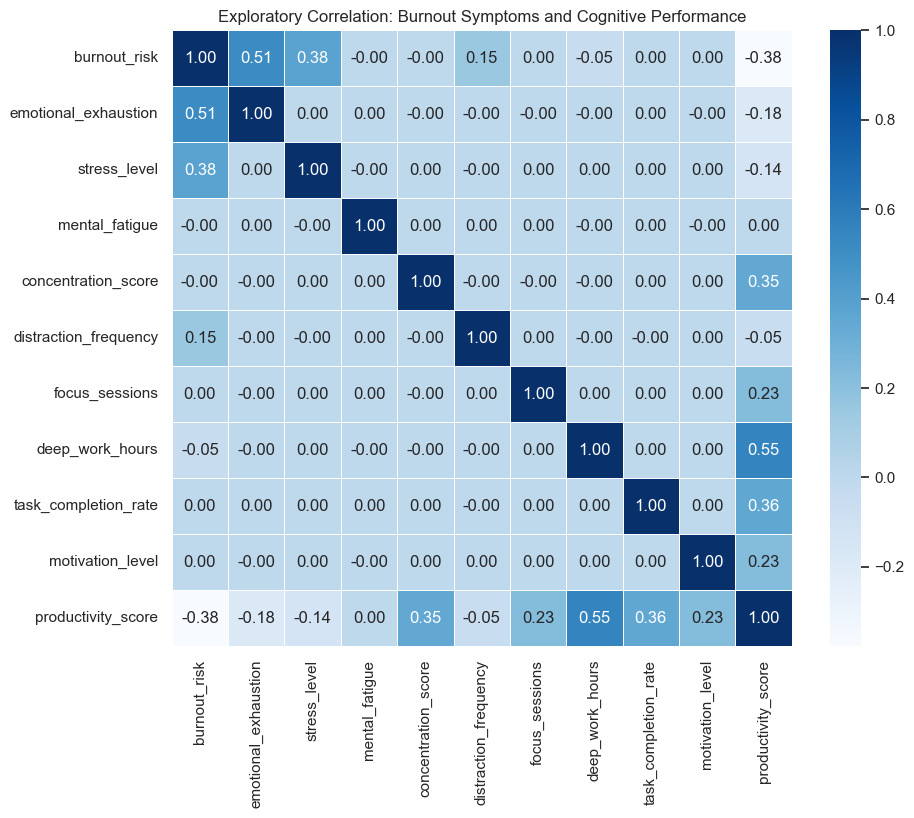

In [24]:
burnout_cognitive_columns = burnout_variables + cognitive_variables

burnout_cognitive_corr = plot_correlation_heatmap(
    df,
    burnout_cognitive_columns,
    "Exploratory Correlation: Burnout Symptoms and Cognitive Performance"
)

## 11. Burnout and Sleep & Recovery Relationship

Phần này quan sát sơ bộ mối quan hệ giữa Burnout Symptoms và Sleep & Recovery.

Mục tiêu:

- Khám phá vai trò của giấc ngủ trong Digital Burnout.
- Chuẩn bị cho việc kiểm chứng nhóm chỉ báo Sleep & Recovery trong DBI.

Không thực hiện kiểm định thống kê chính thức ở đây.

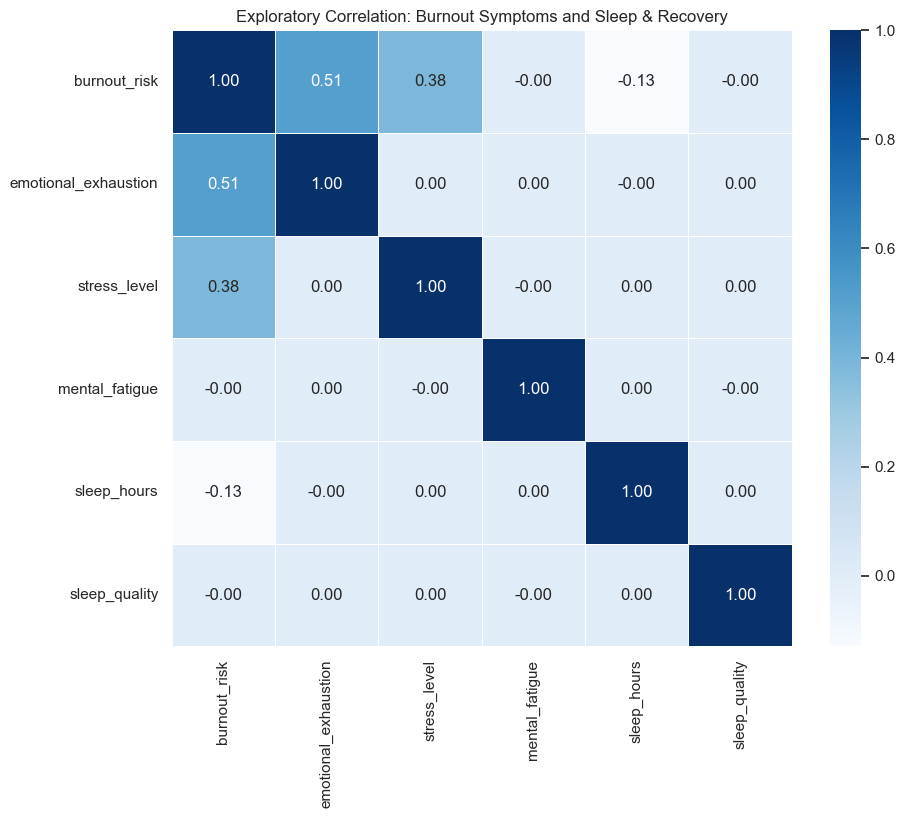

In [25]:
burnout_sleep_columns = burnout_variables + sleep_recovery_variables

burnout_sleep_corr = plot_correlation_heatmap(
    df,
    burnout_sleep_columns,
    "Exploratory Correlation: Burnout Symptoms and Sleep & Recovery"
)

## 12. Exploratory Group Comparison

Phần này quan sát sự khác biệt sơ bộ về `burnout_risk` giữa các nhóm bối cảnh.

Các nhóm được xem xét:

- work_mode
- device_usage_type

Mục tiêu:

- Xem burnout có khác biệt trực quan giữa các nhóm hay không.
- Tạo cơ sở cho kiểm định chính thức trong notebook Feature Validation.

Không sử dụng ANOVA, Kruskal-Wallis hoặc Chi-square trong notebook này.

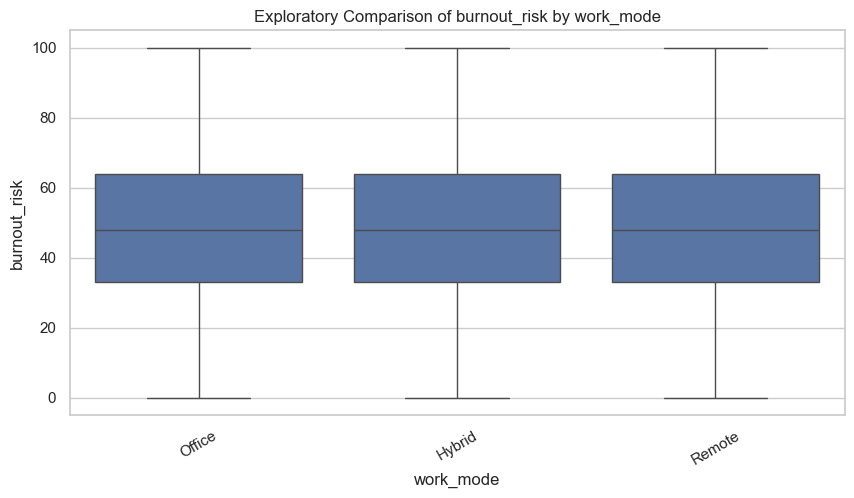

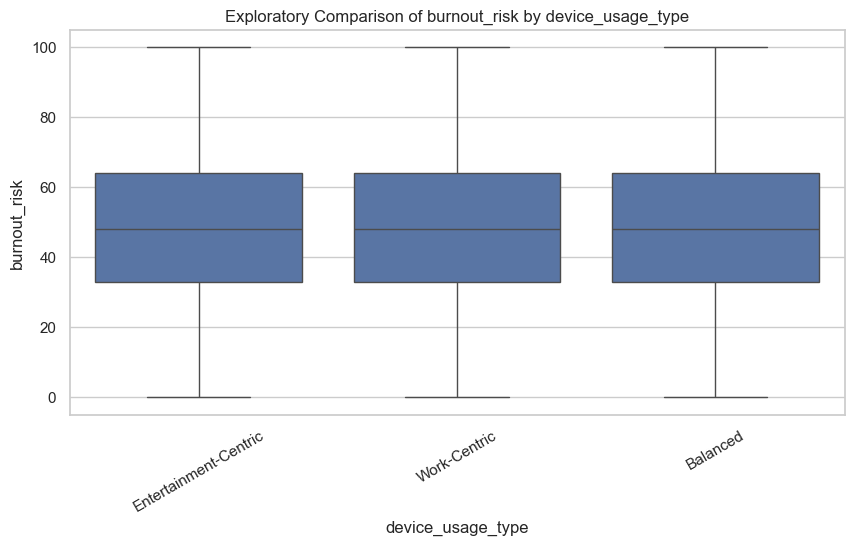

In [26]:
target_variable = "burnout_risk"

if target_variable in df.columns:
    for col in context_variables:
        plt.figure(figsize=(10, 5))
        sns.boxplot(
            data=df,
            x=col,
            y=target_variable
        )
        plt.title(f"Exploratory Comparison of {target_variable} by {col}")
        plt.xlabel(col)
        plt.ylabel(target_variable)
        plt.xticks(rotation=30)
        plt.show()
else:
    print(f"Target variable '{target_variable}' not found in dataset.")

In [27]:
if target_variable in df.columns:
    for col in context_variables:
        group_summary = (
            df.groupby(col)[target_variable]
            .agg(["count", "mean", "median", "std", "min", "max"])
            .reset_index()
        )
        
        print(f"Exploratory group summary: {target_variable} by {col}")
        display(group_summary)

Exploratory group summary: burnout_risk by work_mode


,work_mode,count,mean,median,std,min,max
0,Hybrid,1748165,48.584884,48.0,22.078244,0,100
1,Office,1001061,48.579393,48.0,22.070213,0,100
2,Remote,2250774,48.584794,48.0,22.068020,0,100


Exploratory group summary: burnout_risk by device_usage_type


,device_usage_type,count,mean,median,std,min,max
0,Balanced,1749883,48.591863,48.0,22.059444,0,100
1,Entertainment-Centric,1500738,48.583098,48.0,22.076044,0,100
2,Work-Centric,1749379,48.576177,48.0,22.081180,0,100


## 13. Construct-Level Summary Table

Phần này tạo bảng tổng hợp ở cấp độ construct.

Mục tiêu:

- Tóm tắt trung bình, độ lệch chuẩn, giá trị nhỏ nhất và lớn nhất của từng nhóm chỉ báo.
- Chuẩn bị output cho Feature Validation và DBI Development.

In [28]:
construct_level_summary_rows = []

for construct_name, variables in construct_groups.items():
    numeric_variables = [
        col for col in variables
        if col in df.columns and pd.api.types.is_numeric_dtype(df[col])
    ]
    
    for col in numeric_variables:
        construct_level_summary_rows.append({
            "construct_group": construct_name,
            "variable": col,
            "mean": df[col].mean(),
            "median": df[col].median(),
            "std": df[col].std(),
            "min": df[col].min(),
            "max": df[col].max()
        })

construct_level_summary = pd.DataFrame(construct_level_summary_rows)

display(construct_level_summary)

,construct_group,variable,mean,median,std,min,max
0,Burnout Symptoms,burnout_risk,48.583744,48.0,22.072030,0.0,100.0
1,Burnout Symptoms,emotional_exhaustion,5.502012,6.0,2.871822,1.0,10.0
2,Burnout Symptoms,stress_level,5.499488,5.0,2.871430,1.0,10.0
3,Burnout Symptoms,mental_fatigue,5.499560,5.0,2.872018,1.0,10.0
4,Digital Exposure,daily_screen_time,8.001010,8.0,2.494805,1.0,18.0
5,Digital Exposure,social_media_hours,3.517298,3.5,1.741753,0.0,12.0
6,Digital Exposure,doomscrolling_duration,1.834645,1.8,1.132208,0.0,7.9
7,Digital Exposure,late_night_device_usage,0.649993,1.0,0.476972,0.0,1.0
8,Digital Exposure,notification_count,209.437953,209.0,109.664564,20.0,399.0
9,Digital Exposure,smartphone_unlocks,157.043114,157.0,82.281616,15.0,299.0


## 14. EDA Findings Summary

Bảng này tổng hợp các phát hiện EDA ở mức mô tả.

Lưu ý:

Các phát hiện này chưa phải kết luận học thuật cuối cùng.

Chúng được dùng để định hướng cho:

- Feature Validation
- DBI Development
- Cross-Dataset Comparative Analysis

In [29]:
eda_findings_summary = pd.DataFrame({
    "construct_group": [
        "Burnout Symptoms",
        "Digital Exposure",
        "Cognitive Performance",
        "Sleep & Recovery",
        "Context Variables",
        "Cross-Construct Relationships"
    ],
    "eda_focus": [
        "Distribution and internal relationship of burnout-related variables",
        "Patterns of digital device and social media exposure",
        "Patterns of concentration, focus, motivation, and productivity",
        "Patterns of sleep duration and sleep quality",
        "Distribution of work mode and device usage contexts",
        "Exploratory relationships between burnout and other construct groups"
    ],
    "implication_for_DBI": [
        "Candidate burnout indicators can be examined further in Feature Validation",
        "Digital exposure indicators may contribute to DBI if validated statistically",
        "Cognitive performance indicators may reflect functional impact of burnout",
        "Sleep and recovery indicators may represent protective or recovery dimension",
        "Context variables may support subgroup analysis and comparative interpretation",
        "Observed patterns can guide formal validation but cannot confirm indicator validity"
    ],
    "next_step": [
        "Feature Validation",
        "Feature Validation",
        "Feature Validation",
        "Feature Validation",
        "Exploratory subgroup analysis or Feature Validation",
        "Feature Validation and DBI refinement"
    ]
})

display(eda_findings_summary)

,construct_group,eda_focus,implication_for_DBI,next_step
0,Burnout Symptoms,Distribution and internal relationship of burn...,Candidate burnout indicators can be examined f...,Feature Validation
1,Digital Exposure,Patterns of digital device and social media ex...,Digital exposure indicators may contribute to ...,Feature Validation
2,Cognitive Performance,"Patterns of concentration, focus, motivation, ...",Cognitive performance indicators may reflect f...,Feature Validation
3,Sleep & Recovery,Patterns of sleep duration and sleep quality,Sleep and recovery indicators may represent pr...,Feature Validation
4,Context Variables,Distribution of work mode and device usage con...,Context variables may support subgroup analysi...,Exploratory subgroup analysis or Feature Valid...
5,Cross-Construct Relationships,Exploratory relationships between burnout and ...,Observed patterns can guide formal validation ...,Feature Validation and DBI refinement


## 15. EDA Outputs

Output của notebook này gồm:

1. Construct-based descriptive statistics
2. Distribution plots
3. Boxplots
4. Exploratory correlation heatmaps
5. Exploratory group comparison
6. Construct-level summary table
7. EDA findings summary

Các output này sẽ được sử dụng cho notebook:

`04_feature_validation_and_DBI.ipynb`

In [30]:
eda_output_summary = pd.DataFrame({
    "output": [
        "Construct descriptive statistics",
        "Distribution plots",
        "Boxplots",
        "Exploratory correlation heatmaps",
        "Exploratory group comparison",
        "Construct-level summary table",
        "EDA findings summary"
    ],
    "purpose": [
        "Understand central tendency and dispersion by construct",
        "Explore shape and skewness of variable distributions",
        "Observe potential extreme values",
        "Explore relationships between construct groups",
        "Observe subgroup patterns without formal testing",
        "Summarize indicators at construct level",
        "Prepare insights for Feature Validation and DBI"
    ],
    "used_for_next_stage": [
        "Feature Validation",
        "Feature Validation",
        "EDA interpretation",
        "Feature Validation",
        "Feature Validation",
        "DBI Development",
        "Feature Validation and Comparative Analysis"
    ]
})

display(eda_output_summary)

,output,purpose,used_for_next_stage
0,Construct descriptive statistics,Understand central tendency and dispersion by ...,Feature Validation
1,Distribution plots,Explore shape and skewness of variable distrib...,Feature Validation
2,Boxplots,Observe potential extreme values,EDA interpretation
3,Exploratory correlation heatmaps,Explore relationships between construct groups,Feature Validation
4,Exploratory group comparison,Observe subgroup patterns without formal testing,Feature Validation
5,Construct-level summary table,Summarize indicators at construct level,DBI Development
6,EDA findings summary,Prepare insights for Feature Validation and DBI,Feature Validation and Comparative Analysis
